# Compute vorticity, strain. Plot PACE variables in vorticity-strain space. 

### Please take care while interpreting results.
***Important note***: There are places labeled 'To do' in this script... if you will change the data, please look at these areas of the script to modify as well.

authors: SEL, LJK

In [1]:
import earthaccess,csv
import xarray as xr
from xarray.backends.api import open_datatree
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
from scipy.ndimage import generic_filter
from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata
from scipy.ndimage import median_filter
# %pip install utm
# import utm
from scipy.interpolate import LinearNDInterpolator

# Select eddy below: input correct filenames and dates

In [2]:
date_requested = '20240508' #select date of common SWOT/PACE overlap
pacedate="2024-05-08"

In [3]:
moanapath='/home/jovyan/go-swace/data/moana/moana_Edward_05082024.nc'

In [6]:
moana_ds = xr.open_dataset(moanapath) # should rename this with file extention .nc

In [7]:
clouds = (0, 100) #needs to be clouds = (0, 50) for edward

In [8]:
aviso_ds = xr.open_dataset('/home/jovyan/go-swace/data/eddy_trajectories/Edward_Eddy_trajectory_nrt_3.2exp_cyclonic_20180101_20240723.nc')
specialid='eddy_IDedward'

In [9]:
ind = np.where(aviso_ds.time == np.datetime64(pacedate))[0][0]
contour_lons = np.array(aviso_ds.effective_contour_longitude[ind])
contour_lats = np.array(aviso_ds.effective_contour_latitude[ind])

In [10]:
dates = [i for i in aviso_ds.time.values] # these are sorted already
print(min(dates))
print(max(dates)) # still existed at the end of the dataset
tminny=str(min(dates))
tminny=tminny[0:10]
tmaxxy=str(max(dates))
tmaxxy=tmaxxy[0:10]
tmin,tmax = tminny,tmaxxy
center_lats = [i for i in aviso_ds.latitude.values]
center_lons = [i for i in aviso_ds.longitude.values]
print(len(center_lats))
#Define box based on eddy
latmin,latmax = min(center_lats)-2,max(center_lats)+2
lonmin,lonmax = min(center_lons)-360-2,max(center_lons)-360+2

2023-12-14T00:00:00.000000000
2024-07-23T00:00:00.000000000
223


In [11]:
# Set default fontsizes for plots
fontsize = 18

plt.rc('font', size=fontsize)          # controls default text sizes
plt.rc('axes', titlesize=fontsize)     # fontsize of the axes title
plt.rc('axes', labelsize=fontsize)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=fontsize)    # fontsize of the tick labels
plt.rc('ytick', labelsize=fontsize)    # fontsize of the tick labels
plt.rc('legend', fontsize=fontsize)    # legend fontsize
plt.rc('figure', titlesize=fontsize)  # fontsize of the figure title

In [12]:
def get_swot_data(latmin,latmax,lonmin,lonmax,tmin,tmax):
    """
    Searches for SWOT data within the bounding box and time. Note that this doesn't work for unsmoothed data. 
    
    latmin,latmax: latitude bounds, degrees N (south is negative); floats
    lonmin, lonmax: longitude bounds, degrees E (west is negative); floats
    tmin,tmax: temporal bounds; strings of form 'yyyy-mm-dd'
    """
    bbox = (lonmin, latmin, lonmax, latmax) # lonW, latS, lonE, latN
    results = earthaccess.search_data(
        short_name="SWOT_L2_LR_SSH_EXPERT_2.0",
        bounding_box=bbox,
        temporal=(tmin,tmax))
    
    print("Number of swaths: " + str(len(results))) # not daily files, so will likely be more than # of days
    paths = earthaccess.open(results) # is there a way to choose a subset of variables here?

    return paths

In [13]:
edward_paths = get_swot_data(latmin,latmax,lonmin,lonmax,tmin,tmax)

Number of swaths: 242


QUEUEING TASKS | :   0%|          | 0/242 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/242 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/242 [00:00<?, ?it/s]

In [14]:
ind = 0 
for i in edward_paths:
    today = str(i).split('-')[-1].split('_')[-4][0:8]
    if date_requested == today:
        print(ind)
        sel=ind
    ind += 1

166
167


In [15]:
ds1 = xr.open_dataset(edward_paths[sel])
ds2 = xr.open_dataset(edward_paths[sel-1])

In [16]:
def crop_dataset_by_lat_lon(ds,latmin,latmax,lonmin,lonmax):
    mask = (ds.latitude >= latmin) & (ds.latitude <= latmax) & (ds.longitude >= lonmin+360) & (ds.longitude <= lonmax+360)
    ds_masked = ds.where(mask, drop=True)
    return ds_masked

In [17]:
ds1_masked = crop_dataset_by_lat_lon(ds1,latmin,latmax,lonmin,lonmax)
ds2_masked = crop_dataset_by_lat_lon(ds2,latmin,latmax,lonmin,lonmax)

In [18]:
# Quick velocities: need to change
xv = np.arange(lonmin+360, lonmax+360, 0.036)
yv = np.arange(latmin,latmax, 0.036)
grid_x, grid_y = np.meshgrid(xv, yv)

def quick_velocities(ds, grid_x, grid_y):
    ssh=ds.ssha_karin_2+ds.height_cor_xover
    lats=ds.latitude
    lons=ds.longitude
    grid_ssh = griddata((lons.values.ravel(),lats.values.ravel()), ssh.values.ravel(), (grid_x, grid_y), method='linear')
    return grid_ssh

In [19]:
def compute_geos_current(ssh,lat):
    """
    ssh: (m) Make sure this is first corrected with height_cor_xover from L2 data! 
    lat: degrees N
    """
    
    omega = 7.2921159e-05  # angular velocity of the Earth [rad/s]
    fc = 2*omega*np.sin(lat*np.pi/180.)
        
    # avoid zero near equator, bound fc by min val as 1.e-8
    f_coriolis = np.sign(fc)*np.maximum(np.abs(fc), 1.e-8)
    
    dx,dy = 4000,4000 # m i changed it to 4000 to match res? need to double check
    gravity = 9.81

    dsdy,dsdx=np.array(np.gradient(ssh, dx, edge_order=1))
    vg = (gravity/np.array(f_coriolis))*dsdx
    ug = -(gravity/np.array(f_coriolis))*dsdy
    geos_current = np.sqrt(ug**2 + vg**2)
    
    return ug,vg,geos_current

In [20]:
grid_ssh1 = quick_velocities(ds1_masked, grid_x, grid_y)
grid_ssh2 = quick_velocities(ds2_masked, grid_x, grid_y)

In [21]:
#Calculate
ug1,vg1,geos_current1 = compute_geos_current(grid_ssh1,grid_y)
ug2,vg2,geos_current2 = compute_geos_current(grid_ssh2,grid_y)

<Figure size 640x480 with 0 Axes>

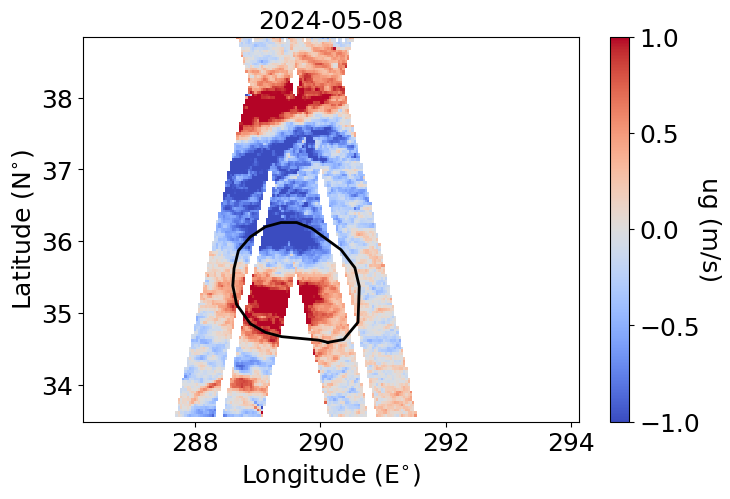

<Figure size 640x480 with 0 Axes>

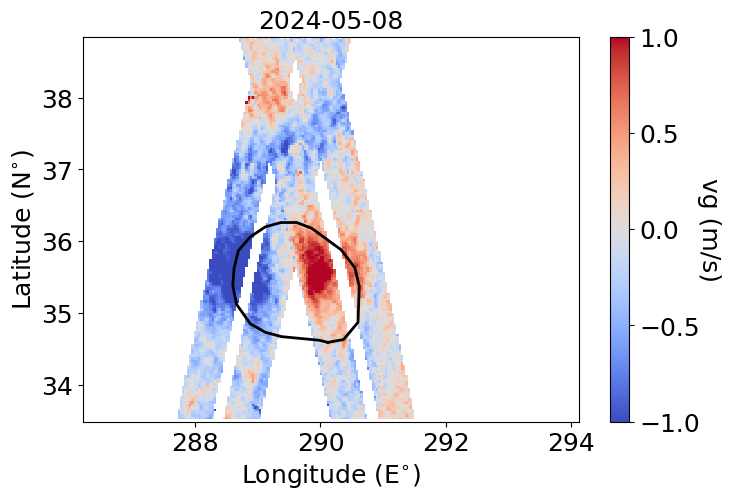

In [22]:
plt.clf()

fig,ax=plt.subplots(figsize=(8,5))
plot = ax.pcolormesh(grid_x,grid_y,ug1,cmap='coolwarm',vmin=-1,vmax=1)
plot = ax.pcolormesh(grid_x,grid_y,ug2,cmap='coolwarm',vmin=-1,vmax=1)
ax.plot(contour_lons,contour_lats,zorder=100,c='k',linewidth=2)

cbar = plt.colorbar(plot,ax=ax)

cbar.set_label('ug (m/s)', rotation=270, labelpad=15)

ax.set_ylabel('Latitude (N$^{\circ}$)')
ax.set_xlabel('Longitude (E$^{\circ}$)')
ax.set_title('%s-%s-%s'%(date_requested[0:4],date_requested[4:6],date_requested[6:8]))

plt.show()

plt.clf()

fig,ax=plt.subplots(figsize=(8,5))
plot = ax.pcolormesh(grid_x,grid_y,vg1,cmap='coolwarm',vmin=-1,vmax=1)
plot = ax.pcolormesh(grid_x,grid_y,vg2,cmap='coolwarm',vmin=-1,vmax=1)
ax.plot(contour_lons,contour_lats,zorder=100,c='k',linewidth=2)

cbar = plt.colorbar(plot,ax=ax)

cbar.set_label('vg (m/s)', rotation=270, labelpad=15)

ax.set_ylabel('Latitude (N$^{\circ}$)')
ax.set_xlabel('Longitude (E$^{\circ}$)')
ax.set_title('%s-%s-%s'%(date_requested[0:4],date_requested[4:6],date_requested[6:8]))

plt.show()

In [23]:
def compute_vort_strain(ug, vg, lon, lat):
    omega = 7.2921159e-05  # angular velocity of the Earth [rad/s]
    fc = 2*omega*np.sin(lat*np.pi/180.)
    # avoid zero near equator, bound fc by min val as 1.e-8
    f_coriolis = np.sign(fc)*np.maximum(np.abs(fc), 1.e-8)
    
    dx,dy = 4000, 4000 # m
    # dx, dy = jxr.tools.geometry.compute_spatial_step(lon, lat)
    du_dy, du_dx = np.gradient(ug, dx, edge_order=2)
    dv_dy, dv_dx = np.gradient(vg, dx, edge_order=2)
    
    ksi = (dv_dx - du_dy)/f_coriolis
    sigma= np.sqrt((du_dx - dv_dy)**2 + (du_dy + dv_dx) ** 2)
    sigma=sigma/f_coriolis 
    
    return ksi, sigma

In [29]:
wfl=5
ug_smooth1=xr.apply_ufunc(generic_filter,ug1, np.mean, [wfl,wfl])
vg_smooth1=xr.apply_ufunc(generic_filter,vg1, np.mean, [wfl,wfl])
ug_smooth2=xr.apply_ufunc(generic_filter,ug2, np.mean, [wfl,wfl])
vg_smooth2=xr.apply_ufunc(generic_filter,vg2, np.mean, [wfl,wfl])

In [30]:
ksi, sigma =compute_vort_strain(ug_smooth1,vg_smooth1,grid_x,grid_y)
ksi2, sigma2 =compute_vort_strain(ug_smooth2,vg_smooth2,grid_x,grid_y)

(33.7, 39.0)

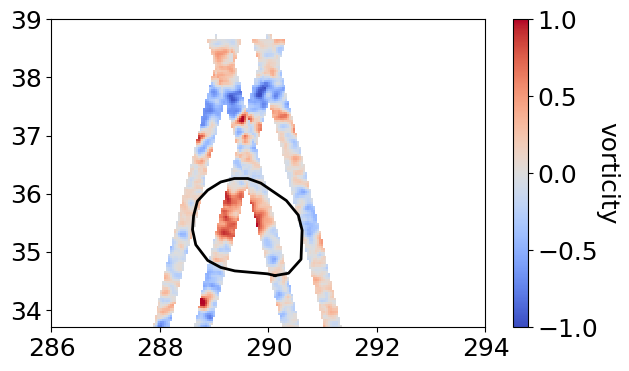

In [31]:
fig,ax=plt.subplots(figsize=(7,4))
plot = ax.pcolormesh(grid_x,grid_y,ksi, shading='auto',cmap='coolwarm',vmin=-1,vmax=1)  # 'shading' option can adjust how cells are rendered
plot = ax.pcolormesh(grid_x, grid_y, ksi2, shading='auto',cmap='coolwarm',vmin=-1,vmax=1)  # 'shading' option can adjust how cells are rendered
ax.plot(contour_lons,contour_lats,zorder=100,c='k',linewidth=2)
cbar = plt.colorbar(plot,ax=ax)
cbar.set_label('vorticity', rotation=270, labelpad=15)
# ax.axis('equal')
# ax.set_xlim([288,292])
# ax.set_ylim([33.8,38])
# ax.set_ylabel('Latitude (N$^{\circ}$)')
# ax.set_xlabel('Longitude (E$^{\circ}$)')
# ax.set_title('%s-%s-%s'%(date_requested[0:4],date_requested[4:6],date_requested[6:8]))
ax.set_xlim([286,294])
ax.set_ylim([33.7,39 ])

Text(0.5, 1.0, '2024-05-08')

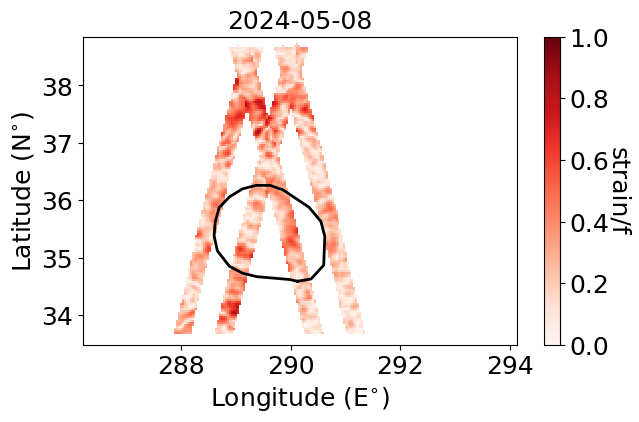

In [33]:
fig,ax=plt.subplots(figsize=(7,4))
plot = ax.pcolormesh(grid_x,grid_y,sigma, shading='auto',cmap='Reds',vmin=0,vmax=1)  # 'shading' option can adjust how cells are rendered
plot = ax.pcolormesh(grid_x, grid_y, sigma2, shading='auto',cmap='Reds',vmin=0,vmax=1)  # 'shading' option can adjust how cells are rendered
ax.plot(contour_lons,contour_lats,zorder=100,c='k',linewidth=2)
cbar = plt.colorbar(plot,ax=ax)
cbar.set_label('strain/f', rotation=270, labelpad=15)
# ax.axis('equal')
# ax.set_xlim([288,292])
# ax.set_ylim([33.8,38])
ax.set_ylabel('Latitude (N$^{\circ}$)')
ax.set_xlabel('Longitude (E$^{\circ}$)')
ax.set_title('%s-%s-%s'%(date_requested[0:4],date_requested[4:6],date_requested[6:8]))

In [39]:
results = earthaccess.search_datasets(instrument="oci")
tspan=(pacedate,pacedate)
bbox = (lonmin+2, latmin+2, lonmax-2, latmax-2)
results = earthaccess.search_data(
    short_name="PACE_OCI_L2_BGC",
    temporal=tspan,
    bounding_box=bbox,
    cloud_cover=clouds,
)

paths = earthaccess.open(results) #'streaming' data

datatree = open_datatree(paths[1]) #To do: might have to change 0 to 1 depending on what the clear image is...
datatree
dataset = xr.merge(datatree.to_dict().values())
dataset
dataset = dataset.set_coords(("longitude", "latitude"))

QUEUEING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/2 [00:00<?, ?it/s]

In [40]:
lat=dataset['latitude']
lon=dataset['longitude']
chl=dataset['chlor_a']
newchl=griddata((lon.values.ravel()+360,lat.values.ravel()),chl.values.ravel(),(grid_x,grid_y), method='linear')

Text(0.5, 1.0, '2024-05-08')

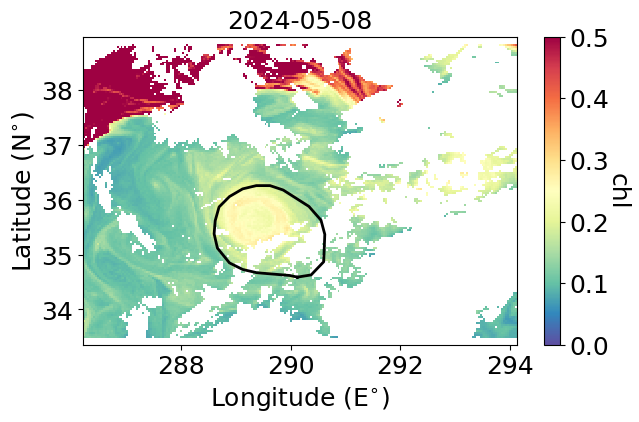

In [42]:
fig,ax=plt.subplots(figsize=(7,4))
plot = ax.pcolormesh(grid_x,grid_y,newchl, shading='auto',cmap='Spectral_r',vmin=0,vmax=0.5)  # 'shading' option can adjust how cells are rendered
ax.plot(contour_lons,contour_lats,zorder=100,c='k',linewidth=2)
cbar = plt.colorbar(plot,ax=ax)
cbar.set_label('chl', rotation=270, labelpad=15)
ax.axis('equal')
# ax.set_xlim([288,292])
# ax.set_ylim([33.8,38])
ax.set_ylabel('Latitude (N$^{\circ}$)')
ax.set_xlabel('Longitude (E$^{\circ}$)')
ax.set_title('%s-%s-%s'%(date_requested[0:4],date_requested[4:6],date_requested[6:8]))

In [53]:
# To do: cut out Gulf stream
ksi[grid_y>37]=np.nan

Text(0.5, 1.0, '2024-05-08')

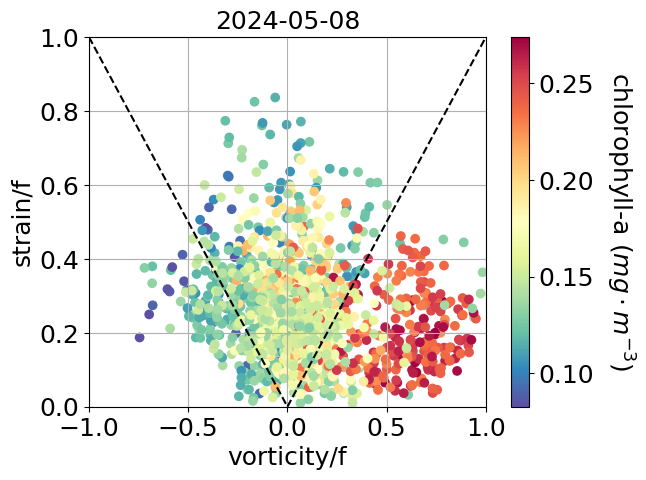

In [56]:
fig = plt.figure()
ax = plt.axes()
plot=plt.scatter(ksi,sigma,c=newchl, cmap="Spectral_r")
#plot=plt.scatter(np.flip(ksi),np.flip(sigma),c=np.flip(newchl), cmap="Spectral_r")

ax.axline((0, 0), slope=-1, color='black',linestyle='--')
ax.axline((0, 0), slope=1, color='black',linestyle='--')
ax.grid(True)
cbar = plt.colorbar(plot,ax=ax)
cbar.set_label('chlorophyll-a ($mg\cdot m^{-3}$)', rotation=270, labelpad=30)
ax.set_ylim([0, 1])
ax.set_xlim([-1, 1])
ax.set_ylabel('strain/f')
ax.set_xlabel('vorticity/f')
ax.set_title('%s-%s-%s'%(date_requested[0:4],date_requested[4:6],date_requested[6:8]))

In [57]:
lon = moana_ds.variables['longitude'] 
lat = moana_ds.variables['latitude'] 
pro = moana_ds.variables['prococcus_moana']
pico = moana_ds.variables['picoeuk_moana'] 
syn = moana_ds.variables['syncoccus_moana']

newpro=griddata((lon.values.ravel()+360,lat.values.ravel()),pro.values.ravel(),(grid_x,grid_y), method='linear')
newpico=griddata((lon.values.ravel()+360,lat.values.ravel()),pico.values.ravel(),(grid_x,grid_y), method='linear')
newsyn=griddata((lon.values.ravel()+360,lat.values.ravel()),syn.values.ravel(),(grid_x,grid_y), method='linear')

NEXT: plot distance to the core
PCA: vorticity, strain, distance to core, speed, 

Text(0.5, 0, 'vorticity/f')

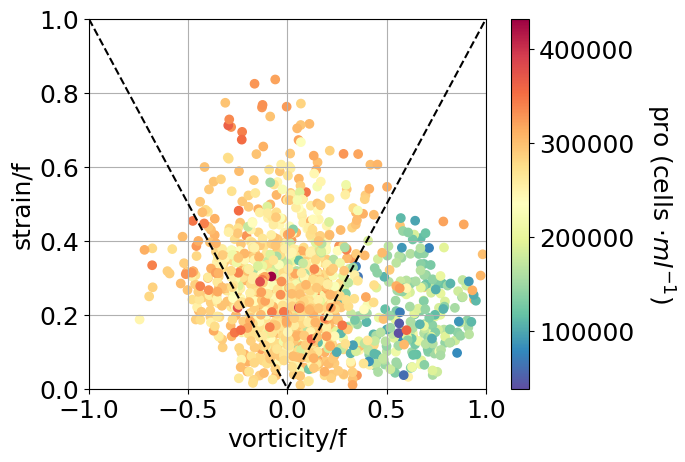

In [58]:
fig = plt.figure()
ax = plt.axes()
plot=plt.scatter(ksi,sigma,c=newpro, cmap="Spectral_r")
ax.axline((0, 0), slope=-1, color='black',linestyle='--')
ax.axline((0, 0), slope=1, color='black',linestyle='--')
ax.grid(True)
cbar = plt.colorbar(plot,ax=ax)
cbar.set_label('pro (cells $ \cdot ml^{-1}$)', rotation=270, labelpad=30)
ax.set_ylim([0, 1])
ax.set_xlim([-1, 1])
ax.set_ylabel('strain/f')
ax.set_xlabel('vorticity/f')

Text(0.5, 0, 'vorticity/f')

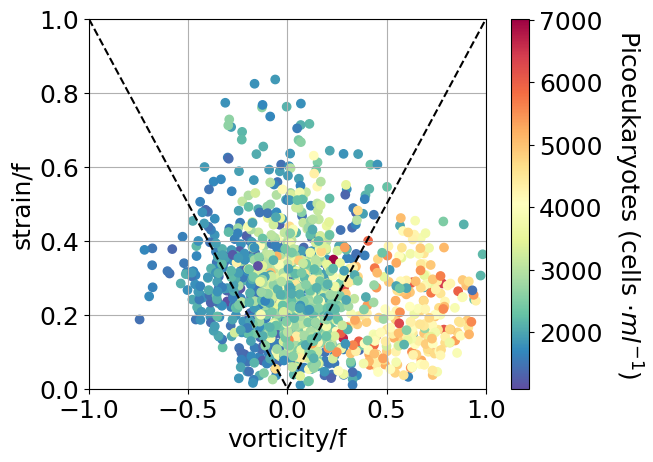

In [59]:
fig = plt.figure()
ax = plt.axes()
plot=plt.scatter(ksi,sigma,c=newpico, cmap="Spectral_r")
ax.axline((0, 0), slope=-1, color='black',linestyle='--')
ax.axline((0, 0), slope=1, color='black',linestyle='--')
ax.grid(True)
cbar = plt.colorbar(plot,ax=ax)
ax.set_ylim([0, 1])
ax.set_xlim([-1, 1])
cbar.set_label('Picoeukaryotes (cells $ \cdot ml^{-1}$)', rotation=270, labelpad=30)
ax.set_ylabel('strain/f')
ax.set_xlabel('vorticity/f')

Text(0.5, 0, 'vorticity/f')

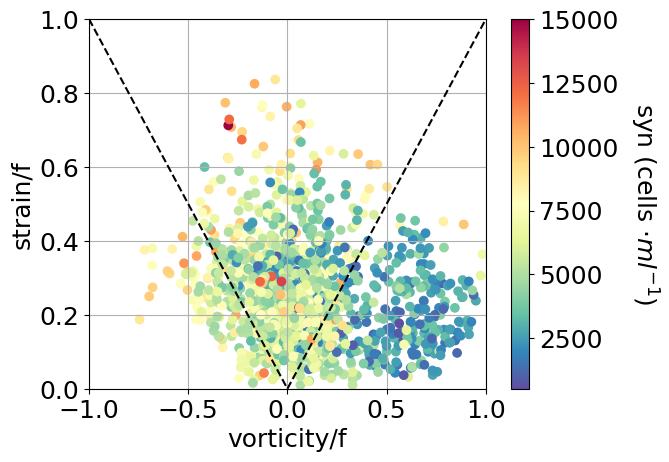

In [60]:
fig = plt.figure()
ax = plt.axes()
plot=plt.scatter(ksi,sigma,c=newsyn, cmap="Spectral_r",vmax=15000)
ax.axline((0, 0), slope=-1, color='black',linestyle='--')
ax.axline((0, 0), slope=1, color='black',linestyle='--')
ax.grid(True)
cbar = plt.colorbar(plot,ax=ax)
ax.set_ylim([0, 1])
ax.set_xlim([-1, 1])
cbar.set_label('syn (cells $ \cdot ml^{-1}$)', rotation=270, labelpad=30)
ax.set_ylabel('strain/f')
ax.set_xlabel('vorticity/f')

Text(0.5, 0, 'vorticity/f')

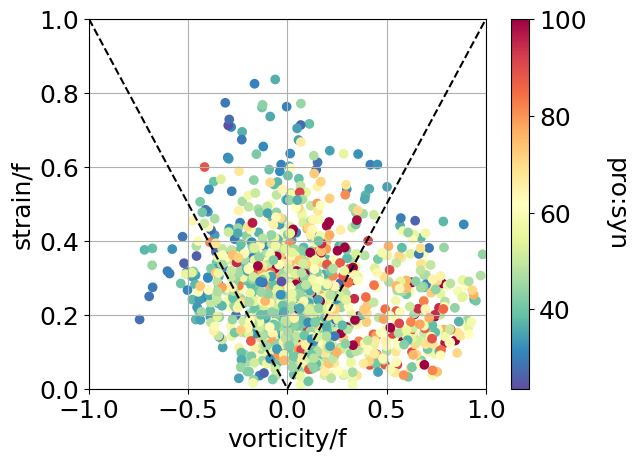

In [61]:
fig = plt.figure()
ax = plt.axes()
plot=plt.scatter(ksi,sigma,c=np.divide(newpro,newsyn), cmap="Spectral_r",vmax=100)
ax.axline((0, 0), slope=-1, color='black',linestyle='--')
ax.axline((0, 0), slope=1, color='black',linestyle='--')
ax.grid(True)
cbar = plt.colorbar(plot,ax=ax)
ax.set_ylim([0, 1])
ax.set_xlim([-1, 1])
cbar.set_label('pro:syn', rotation=270, labelpad=30)
ax.set_ylabel('strain/f')
ax.set_xlabel('vorticity/f')

Text(0.5, 0, 'vorticity/f')

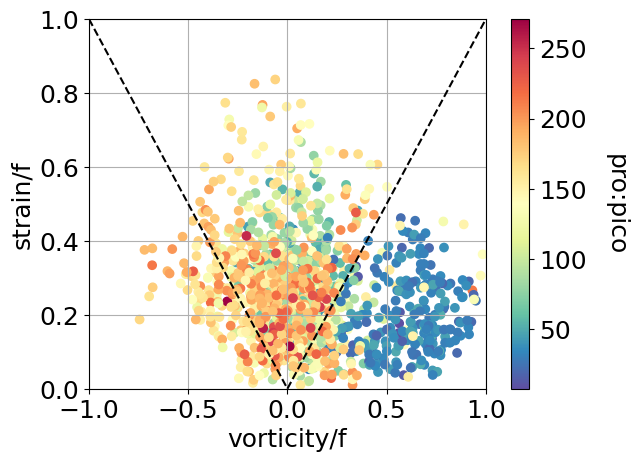

In [62]:
fig = plt.figure()
ax = plt.axes()
# plot=plt.scatter(ksi,sigma,c=np.divide(newpro,newpico), cmap="Spectral_r")
plot=plt.scatter(np.flip(ksi),np.flip(sigma),c=np.divide(np.flip(newpro),np.flip(newpico)), cmap="Spectral_r")
ax.axline((0, 0), slope=-1, color='black',linestyle='--')
ax.axline((0, 0), slope=1, color='black',linestyle='--')
ax.grid(True)
cbar = plt.colorbar(plot,ax=ax)
ax.set_ylim([0, 1])
ax.set_xlim([-1, 1])
cbar.set_label('pro:pico', rotation=270, labelpad=30)
ax.set_ylabel('strain/f')
ax.set_xlabel('vorticity/f')